In [350]:
# Importar bibliotecas
import pandas as pd
import numpy as np
from pathlib import Path


# Ruta base del proyecto
base_path = Path("../data/raw")

# Cargar CSV
customers = pd.read_csv(base_path / "olist_customers_dataset.csv")
geolocation = pd.read_csv(base_path / "olist_geolocation_dataset.csv")
order_items = pd.read_csv(base_path / "olist_order_items_dataset.csv")
order_payments = pd.read_csv(base_path / "olist_order_payments_dataset.csv")
order_reviews = pd.read_csv(base_path / "olist_order_reviews_dataset.csv")
orders = pd.read_csv(base_path / "olist_orders_dataset.csv")
products = pd.read_csv(base_path / "olist_products_dataset.csv")
sellers = pd.read_csv(base_path / "olist_sellers_dataset.csv")
category_translation = pd.read_csv(base_path / "product_category_name_translation.csv")

# Comprobar carga
print("customers:", customers.shape)
print("geolocation:", geolocation.shape)
print("order_items:", order_items.shape)
print("order_payments:", order_payments.shape)
print("order_reviews:", order_reviews.shape)
print("orders:", orders.shape)
print("products:", products.shape)
print("sellers:", sellers.shape)
print("category_translation:", category_translation.shape)

customers: (99441, 5)
geolocation: (1000163, 5)
order_items: (112650, 7)
order_payments: (103886, 5)
order_reviews: (99224, 7)
orders: (99441, 8)
products: (32951, 9)
sellers: (3095, 4)
category_translation: (71, 2)


Las tablas tienen tamaños coherentes entre sí. orders y customers tienen el mismo número de filas, lo que sugiere que en este dataset hay un cliente por pedido, no clientes únicos.
Las transaccionales son las que registran eventos o movimientos del negocio, como orders, order_items, order_payments y order_reviews.
Las maestras son las que describen entidades más estables: customers, products, sellers y también geolocation. category_translation no es maestra principal, sino una tabla auxiliar de correspondencia.La calidad preliminar es buena a nivel de estructura y volumen.

In [351]:
customers.head(10)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP
5,879864dab9bc3047522c92c82e1212b8,4c93744516667ad3b8f1fb645a3116a4,89254,jaragua do sul,SC
6,fd826e7cf63160e536e0908c76c3f441,addec96d2e059c80c30fe6871d30d177,4534,sao paulo,SP
7,5e274e7a0c3809e14aba7ad5aae0d407,57b2a98a409812fe9618067b6b8ebe4f,35182,timoteo,MG
8,5adf08e34b2e993982a47070956c5c65,1175e95fb47ddff9de6b2b06188f7e0d,81560,curitiba,PR
9,4b7139f34592b3a31687243a302fa75b,9afe194fb833f79e300e37e580171f22,30575,belo horizonte,MG


la tabla customers tiene 99.441 registros y 5 columnas, con una estructura limpia, compacta y coherente con una dimensión de clientes. A primera vista contiene identificador del cliente, identificador único, prefijo postal, ciudad y estado.mezcla clave de negocio y variables geográficas, así que servirá para segmentación por ubicación
La tabla customers presenta una estructura consistente, sin ruido aparente en una primera inspección, y contiene atributos identificativos y geográficos útiles para análisis de clientes y segmentación territorial.
que haya dos identificadores distintos suele significar que no representan exactamente lo mismo. customer_id parece el identificador de la instancia del cliente en una compra, y customer_unique_id el identificador del cliente real.

La sospecha sale del propio nombre de la columna: cuando un dataset pone unique_id, normalmente está separando la entidad real de otro ID operativo. Eso suele pasar cuando un mismo cliente puede aparecer varias veces en distintos pedidos.

In [352]:
customers.shape



(99441, 5)

In [353]:
customers.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='object')

In [354]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [355]:
customers.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

customers muestra buena calidad estructural y de completitud, sin nulos y con tipado consistente para una primera fase de exploración.

In [356]:
customers.duplicated().sum()

np.int64(0)

In [357]:
customers.nunique()

customer_id                 99441
customer_unique_id          96096
customer_zip_code_prefix    14994
customer_city                4119
customer_state                 27
dtype: int64

customer_id tiene 99.441 únicos pero customer_unique_id solo 96.096 → un mismo cliente real aparece varias veces. Confirmas la hipótesis: un cliente puede hacer varios pedidos.

Las variables geográficas tienen alta variabilidad (muchos zip/cities) y pocos estados (27), lo esperado. Conclusión: “La tabla refleja granularidad por pedido."

In [358]:
customers.describe()

,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


customer_zip_code_prefix, que es un código, no una variable numérica analítica.Las estadísticas no aportan insight relevante porque el zip code es un identificador geográfico, no una magnitud interpretable (no tiene sentido la media o desviación).No todo lo numérico se analiza igual.

In [359]:
# Valores únicos de estado
customers["customer_state"].unique()
customers["customer_state"].nunique()
customers["customer_state"].value_counts()

# Top 10 ciudades con más registros
customers["customer_city"].value_counts().head(10)

# Top 10 combinaciones ciudad-estado
customers.groupby(["customer_city", "customer_state"]).size().sort_values(ascending=False).head(10)

customer_city          customer_state
sao paulo              SP                15540
rio de janeiro         RJ                 6882
belo horizonte         MG                 2773
brasilia               DF                 2131
curitiba               PR                 1521
campinas               SP                 1444
porto alegre           RS                 1379
salvador               BA                 1245
guarulhos              SP                 1189
sao bernardo do campo  SP                  938
dtype: int64

Distribución geográfica coherente, con concentración en grandes núcleos urbanos y sin inconsistencias aparentes en estados o ciudades

In [360]:
customers.to_csv("../data/processed/customers.csv", index=False)

In [361]:
geolocation.head(10)


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP
5,1012,-23.547762,-46.635361,são paulo,SP
6,1047,-23.546273,-46.641225,sao paulo,SP
7,1013,-23.546923,-46.634264,sao paulo,SP
8,1029,-23.543769,-46.634278,sao paulo,SP
9,1011,-23.547640,-46.636032,sao paulo,SP


In [362]:
geolocation.shape


(1000163, 5)

La tabla geolocation contiene 1.000.163 filas y 5 columnas, con una estructura coherente para una dimensión geográfica. Incluye prefijo de código postal, latitud, longitud, ciudad y estado, por lo que resulta útil para análisis de localización y segmentación territorial.

Por el volumen, conviene validar duplicados y cardinalidad, porque puede haber varios registros para un mismo prefijo postal.

las coordenadas usan hemisferios.
La latitud es negativa cuando está al sur del ecuador, y Brasil está en el hemisferio sur.
La longitud es negativa cuando está al oeste del meridiano de Greenwich, y Brasil también está en el hemisferio oeste.
Así que esos negativos son totalmente correctos y esperables.

In [363]:
geolocation.columns


Index(['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng',
       'geolocation_city', 'geolocation_state'],
      dtype='object')

In [364]:
geolocation.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


In [365]:
geolocation.isnull().sum() 


geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

geolocation muestra buena calidad estructural y de completitud, sin nulos y con tipado consistente para una primera fase de exploración.

In [366]:
geolocation.duplicated().sum() 


np.int64(261831)

In [367]:
geolocation.describe()


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
count,1.000163e+06,1.000163e+06,1.000163e+06
mean,3.657417e+04,-2.117615e+01,-4.639054e+01
std,3.054934e+04,5.715866e+00,4.269748e+00
min,1.001000e+03,-3.660537e+01,-1.014668e+02
25%,1.107500e+04,-2.360355e+01,-4.857317e+01
50%,2.653000e+04,-2.291938e+01,-4.663788e+01
75%,6.350400e+04,-1.997962e+01,-4.376771e+01
max,9.999000e+04,4.506593e+01,1.211054e+02


In [368]:
geolocation.nunique()

geolocation_zip_code_prefix     19015
geolocation_lat                717360
geolocation_lng                717613
geolocation_city                 8011
geolocation_state                  27
dtype: int64

hay muchos duplicados y antes de usar geolocation en joins hay que entender su patrón, porque podría haber varios registros por mismo prefijo postal o combinaciones repetidas de ubicación.
Las estadísticas descriptivas no aportan insights de negocio especialmente relevantes, ya que geolocation_zip_code_prefix actúa como identificador geográfico y geolocation_lat y geolocation_lng son coordenadas espaciales, no magnitudes analíticas interpretables.

In [369]:
geolocation.value_counts().reset_index(name="veces").head(20)

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state,veces
0,88220,-27.102099,-48.629613,itapema,SC,314
1,6414,-23.495901,-46.874687,barueri,SP,189
2,6414,-23.490618,-46.869004,barueri,SP,127
3,5145,-23.506049,-46.717377,sao paulo,SP,126
4,22620,-23.005514,-43.375964,rio de janeiro,RJ,102
5,22775,-22.965906,-43.389999,rio de janeiro,RJ,89
6,22640,-23.004582,-43.319899,rio de janeiro,RJ,89
7,6401,-23.509243,-46.886669,barueri,SP,81
8,71936,-15.841451,-48.024026,brasilia,DF,80
9,30240,-19.924167,-43.916480,belo horizonte,MG,79


In [370]:
geolocation_clean = geolocation.drop_duplicates()

In [371]:
geolocation.shape, geolocation_clean.shape

((1000163, 5), (738332, 5))

Tras eliminar duplicados exactos, la tabla reduce de forma importante su volumen de filas sin perder variables, lo que mejora su eficiencia y la deja más preparada para cruces geográficos.Para una tabla de localizaciones, repetir exactamente la misma fila no aporta información nueva, así que lo lógico es eliminar duplicados.

In [372]:
geolocation_clean.duplicated().sum()

np.int64(0)

In [373]:
geolocation_clean["geolocation_zip_code_prefix"].nunique()

19015

In [374]:
geolocation_clean.shape[0]
geolocation_clean["geolocation_zip_code_prefix"].nunique()

19015

Aunque se han eliminado duplicados exactos, la tabla sigue teniendo múltiples registros por zip_code_prefix, lo que indica granularidad a nivel de coordenadas dentro de un mismo código postal.

In [375]:
geolocation_zip = (
    geolocation_clean
    .groupby("geolocation_zip_code_prefix", as_index=False)
    .agg({
        "geolocation_lat": "mean",
        "geolocation_lng": "mean",
        "geolocation_city": "first",
        "geolocation_state": "first"
    })
)

geolocation_zip.head()
geolocation_zip.shape
geolocation_zip["geolocation_zip_code_prefix"].nunique()

19015

In [376]:
geolocation_zip.duplicated().sum()

np.int64(0)

La tabla geolocation se ha depurado eliminando duplicados y agregando a nivel de zip_code_prefix, obteniendo una única coordenada representativa por código postal, lo que facilita su uso en joins con otras tablas.

In [377]:

geolocation_zip.to_csv("../data/processed/geolocation_zip.csv", index=False)

In [385]:
order_payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


order_id: identificador del pedido. Sirve para saber a qué compra pertenece ese pago.

payment_sequential: número de secuencia del pago dentro del pedido. Si un pedido se pagó en varias partes o métodos, esto marca el orden: 1, 2, 3…

payment_type: tipo de pago. Ejemplo: tarjeta, voucher, boleto, etc.

payment_installments: número de cuotas/plazos. Si pone 8, ese pago se hizo en 8 cuotas. payment_value: importe pagado en esa línea de pago

In [386]:
order_payments.shape 

(103886, 5)

In [387]:
order_payments.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [388]:
order_payments.columns 

Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='object')

In [389]:
order_payments.isnull().sum() 

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [390]:
order_payments.duplicated().sum()

np.int64(0)

In [391]:
order_payments.describe() 

,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


In [392]:
order_payments.to_csv("../data/processed/order_payments.csv", index=False)

order_payments es una tabla transaccional a nivel de pago por pedido: cada fila representa una operación de pago asociada a un order_id.

Tiene buena calidad inicial, porque no presenta nulos ni duplicados.

La mayoría de pedidos parecen tener un único pago (payment_sequential = 1), aunque algunos se dividen en varios pagos o secuencias. También se ve que lo más habitual es pagar en 1 cuota, aunque existen pagos fraccionados hasta en 24.

Es una tabla clave para analizar métodos de pago, importes pagados y uso de cuotas.

In [393]:
order_reviews.head(10)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
5,15197aa66ff4d0650b5434f1b46cda19,b18dcdf73be66366873cd26c5724d1dc,1,NaN,NaN,2018-04-13 00:00:00,2018-04-16 00:39:37
6,07f9bee5d1b850860defd761afa7ff16,e48aa0d2dcec3a2e87348811bcfdf22b,5,NaN,NaN,2017-07-16 00:00:00,2017-07-18 19:30:34
7,7c6400515c67679fbee952a7525281ef,c31a859e34e3adac22f376954e19b39d,5,NaN,NaN,2018-08-14 00:00:00,2018-08-14 21:36:06
8,a3f6f7f6f433de0aefbb97da197c554c,9c214ac970e84273583ab523dfafd09b,5,NaN,NaN,2017-05-17 00:00:00,2017-05-18 12:05:37
9,8670d52e15e00043ae7de4c01cc2fe06,b9bf720beb4ab3728760088589c62129,4,recomendo,aparelho eficiente. no site a marca do aparelh...,2018-05-22 00:00:00,2018-05-23 16:45:47


In [394]:
order_reviews.shape

(99224, 7)

In [395]:
order_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [396]:
order_reviews.columns

Index(['review_id', 'order_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp'],
      dtype='object')

In [397]:
order_reviews.isnull().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [398]:
order_reviews.duplicated().sum()

np.int64(0)

In [399]:
order_reviews.describe()

,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [400]:
# Convertir columnas de fecha
order_reviews['review_creation_date'] = pd.to_datetime(order_reviews['review_creation_date'])
order_reviews['review_answer_timestamp'] = pd.to_datetime(order_reviews['review_answer_timestamp'])


In [401]:
order_reviews['review_score'].value_counts().sort_index()

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

In [402]:
# 2. Calcular tiempo de respuesta en días
order_reviews['tiempo_respuesta_dias'] = (
    order_reviews['review_answer_timestamp'] - order_reviews['review_creation_date']
).dt.total_seconds() / 86400  # convertir a días

In [403]:
# 3. Resumen estadístico
order_reviews['tiempo_respuesta_dias'].describe()

count    99224.000000
mean         3.148993
std          9.890049
min          0.089225
25%          1.004870
50%          1.674948
75%          3.103565
max        518.699213
Name: tiempo_respuesta_dias, dtype: float64

In [404]:
order_reviews.groupby('review_score')['tiempo_respuesta_dias'].mean().round(2)

review_score
1    3.05
2    3.00
3    2.98
4    3.12
5    3.21
Name: tiempo_respuesta_dias, dtype: float64

In [405]:
order_reviews.drop(columns=['review_comment_title'], inplace=True)

Se eliminaron la columna de titulo de comentario porque presentan un volumen muy alto de nulos y no aportan valor al análisis principal del proyecto, centrado en métricas operativas, satisfacción y visualización en SQL/Power BI.

In [406]:
# Rellenar mensajes sin comentario
order_reviews['review_comment_message'].fillna('sin comentario', inplace=True)


C:\Users\elaru\AppData\Local\Temp\ipykernel_18636\870324039.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  order_reviews['review_comment_message'].fillna('sin comentario', inplace=True)


In [407]:
# Verificar que no quedan nulos
order_reviews.isnull().sum()

review_id                  0
order_id                   0
review_score               0
review_comment_message     0
review_creation_date       0
review_answer_timestamp    0
tiempo_respuesta_dias      0
dtype: int64

In [408]:
# Ver cuántos casos superan, por ejemplo, 30 días
order_reviews[order_reviews['tiempo_respuesta_dias'] > 30].shape[0]


682

In [409]:
# Puedes marcarlos con una bandera en vez de eliminarlos
order_reviews['respuesta_atipica'] = order_reviews['tiempo_respuesta_dias'] > 30

In [410]:
import re
import unicodedata


def normalizar_texto(texto):
    # Convertir a string por si hay valores float/NaN
    texto = str(texto)
    
    # 1. Convertir a minúsculas
    texto = texto.lower()
    
    # 2. Eliminar acentos y caracteres especiales del portugués
    texto = unicodedata.normalize('NFKD', texto)
    texto = texto.encode('ascii', 'ignore').decode('utf-8')
    
    # 3. Eliminar puntuación y caracteres especiales
    texto = re.sub(r'[^\w\s]', '', texto)
    
    # 4. Eliminar números
    texto = re.sub(r'\d+', '', texto)
    
    # 5. Eliminar espacios múltiples
    texto = re.sub(r'\s+', ' ', texto)
    
    # 6. Eliminar espacios al inicio y al final
    texto = texto.strip()
    
    return texto

In [411]:

# Aplicar al dataset
order_reviews['comentario_limpio'] = order_reviews['review_comment_message'].apply(normalizar_texto)


In [412]:
# Verificar resultado
order_reviews[['review_comment_message', 'comentario_limpio']].head(10)

,review_comment_message,comentario_limpio
0,sin comentario,sin comentario
1,sin comentario,sin comentario
2,sin comentario,sin comentario
3,Recebi bem antes do prazo estipulado.,recebi bem antes do prazo estipulado
4,Parabéns lojas lannister adorei comprar pela I...,parabens lojas lannister adorei comprar pela i...
5,sin comentario,sin comentario
6,sin comentario,sin comentario
7,sin comentario,sin comentario
8,sin comentario,sin comentario
9,aparelho eficiente. no site a marca do aparelh...,aparelho eficiente no site a marca do aparelho...


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\elaru\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


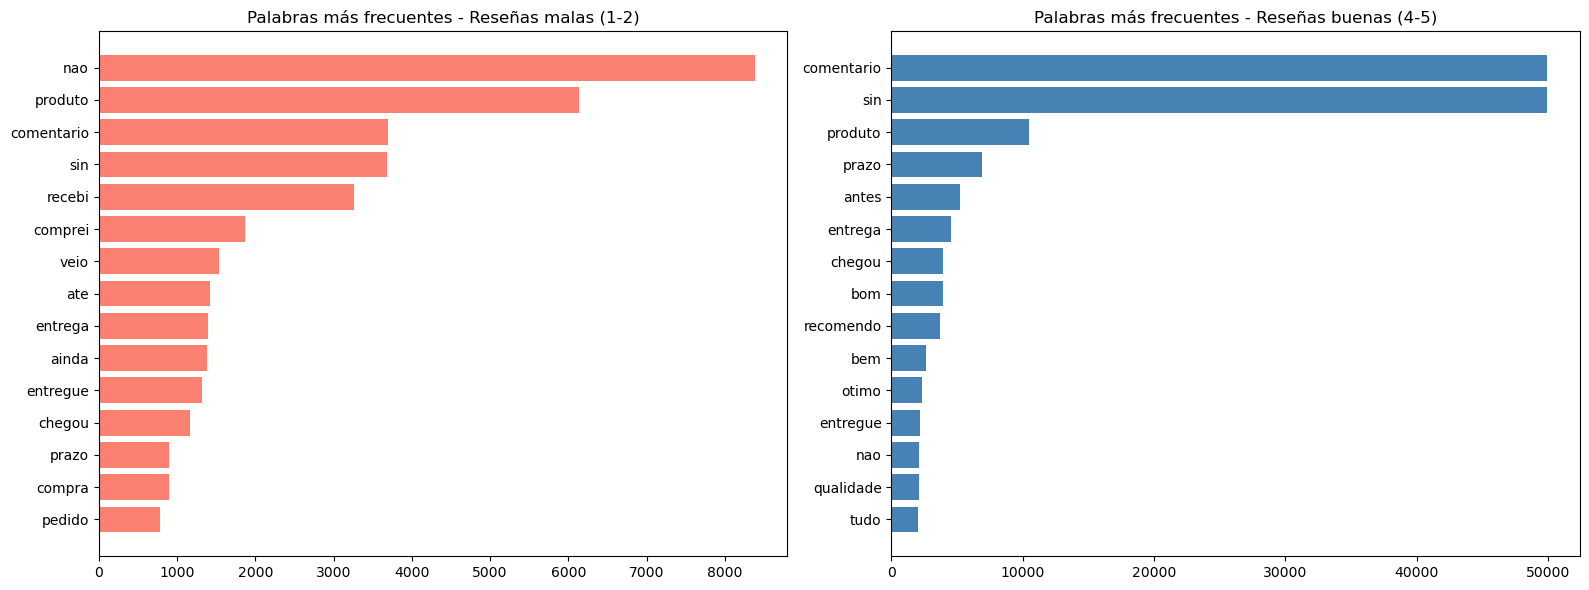

In [413]:
from collections import Counter
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')
stop_pt = set(stopwords.words('portuguese'))

# Filtrar comentarios reales (sin nan)
df_comentarios = order_reviews[order_reviews['comentario_limpio'].notna() & 
                                (order_reviews['comentario_limpio'] != 'nan')]

malas = df_comentarios[df_comentarios['review_score'] <= 2]['comentario_limpio']
buenas = df_comentarios[df_comentarios['review_score'] >= 4]['comentario_limpio']

# Nueva función CON filtro de stopwords
def top_palabras(serie, n=15):
    todas = ' '.join(serie).split()
    filtradas = [p for p in todas if p not in stop_pt and len(p) > 2]
    return Counter(filtradas).most_common(n)

palabras_malas = top_palabras(malas)
palabras_buenas = top_palabras(buenas)

# Graficar
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

palabras, conteos = zip(*palabras_malas)
axes[0].barh(palabras, conteos, color='salmon')
axes[0].set_title('Palabras más frecuentes - Reseñas malas (1-2)')
axes[0].invert_yaxis()

palabras, conteos = zip(*palabras_buenas)
axes[1].barh(palabras, conteos, color='steelblue')
axes[1].set_title('Palabras más frecuentes - Reseñas buenas (4-5)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [414]:
order_reviews.to_csv("../data/processed/order_reviews.csv", index=False)

conclusiones clave

Dataset order_reviews de 99.224 reseñas sin duplicados. Se detectaron nulos en dos columnas: review_comment_title (87.656 nulos, 88%) eliminada por ser redundante, y review_comment_message (58.247 nulos, 59%) conservada con NaN para no perder registros
Las fechas se convirtieron a datetime y se creó la columna tiempo_respuesta_dias. Se identificaron 682 outliers (>30 días) marcados con la bandera respuesta_atipica sin eliminarlos
Distribución fuertemente sesgada hacia 5★ (57,8%). El tiempo de respuesta es uniforme (~3 días) para todas las puntuaciones — sin priorización de reseñas negativas
Los comentarios fueron normalizados (minúsculas, sin acentos, sin puntuación) y analizados con stopwords filtradas. Las reseñas negativas giran en torno a no recibir el pedido; las positivas destacan llegar antes del plazo

In [415]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [416]:
orders.shape


(99441, 8)

In [417]:
orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')

In [418]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [419]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

orders[date_cols].dtypes

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [420]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [421]:
orders.duplicated().sum()

np.int64(0)

In [422]:
orders.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99281,97658,96476,99441
mean,2017-12-31 08:43:12.776581120,2017-12-31 18:35:24.098800128,2018-01-04 21:49:48.138278656,2018-01-14 12:09:19.035542272,2018-01-24 03:08:37.730111232
min,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00
25%,2017-09-12 14:46:19,2017-09-12 23:24:16,2017-09-15 22:28:50.249999872,2017-09-25 22:07:22.249999872,2017-10-03 00:00:00
50%,2018-01-18 23:04:36,2018-01-19 11:36:13,2018-01-24 16:10:58,2018-02-02 19:28:10.500000,2018-02-15 00:00:00
75%,2018-05-04 15:42:16,2018-05-04 20:35:10,2018-05-08 13:37:45,2018-05-15 22:48:52.249999872,2018-05-25 00:00:00
max,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00


In [423]:
#calcula diferencias (tiempos entre etapas)

orders['approval_time_days'] = (
    orders['order_approved_at'] - orders['order_purchase_timestamp']
).dt.total_seconds() / 86400

orders['carrier_time_days'] = (
    orders['order_delivered_carrier_date'] - orders['order_approved_at']
).dt.total_seconds() / 86400

orders['delivery_time_days'] = (
    orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']
).dt.total_seconds() / 86400

orders['estimated_vs_actual_days'] = (
    orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']
).dt.total_seconds() / 86400

orders[['approval_time_days','carrier_time_days','delivery_time_days','estimated_vs_actual_days']].describe()

,approval_time_days,carrier_time_days,delivery_time_days,estimated_vs_actual_days
count,99281.000000,97644.000000,96476.000000,96476.000000
mean,0.434129,2.805038,12.558702,-11.179120
std,1.084917,3.549427,9.546530,10.186113
min,0.000000,-171.219005,0.533414,-146.016123
25%,0.008958,0.875509,6.766403,-16.244384
50%,0.014306,1.818397,10.217755,-11.948941
75%,0.607535,3.580469,15.720327,-6.390000
max,187.882523,125.762569,209.628611,188.975081


In [424]:
#retrasados
(orders['estimated_vs_actual_days'] > 0).sum()

np.int64(7827)

<Axes: >

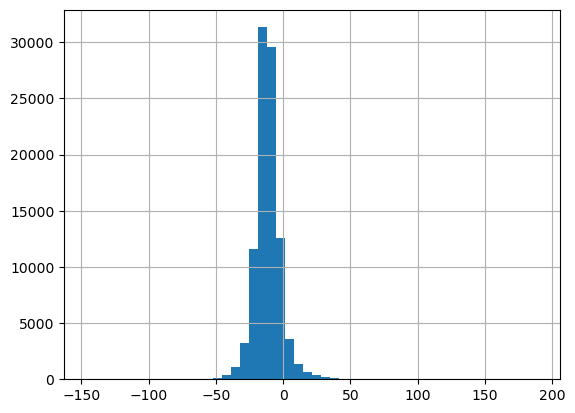

In [425]:
orders['estimated_vs_actual_days'].hist(bins=50)

In [426]:
#para ver qué estados dominan (delivered, shipped, canceled, etc.) y entender el flujo real del negocio.
orders['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [427]:
#Sirve para comprobar si los nulos tienen sentido operativo: por ejemplo, que canceled no tenga fecha de entrega o que delivered sí la tenga.

orders.groupby('order_status')[[
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date'
]].apply(lambda x: x.isnull().sum())

,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date
order_status,,,
approved,0,2,2
canceled,141,550,619
created,5,5,5
delivered,14,2,8
invoiced,0,314,314
processing,0,301,301
shipped,0,0,1107
unavailable,0,609,609


In [428]:
orders.to_csv("../data/processed/orders.csv", index=False)

conclusiones: orders es una tabla de casi 100k pedidos, sin duplicados exactos y con buena calidad estructural inicial. Las columnas de fecha se transformaron correctamente a datetime, lo que permitió analizar el ciclo logístico del pedido.

Los nulos detectados no parecen errores, sino valores coherentes con el estado operativo del pedido: por ejemplo, pedidos cancelados, en procesamiento o no entregados todavía no tienen fechas finales asociadas. Esto refuerza la consistencia del dataset.

El análisis temporal muestra un flujo lógico entre compra, aprobación, envío y entrega. En promedio, los pedidos se entregan antes de la fecha estimada, lo que sugiere una planificación conservadora o una logística eficiente.

Aun así, existen miles de pedidos con retraso y algunos outliers extremos, por lo que, aunque el desempeño general es bueno, hay incidencias logísticas puntuales que pueden afectar la experiencia del cliente.

In [429]:
products.head(5)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [430]:
products.shape

(32951, 9)

In [431]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [432]:
products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [433]:
products[products['product_category_name'].isnull()].head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.0,17.0,14.0,12.0
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.0,16.0,7.0,20.0
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.0,20.0,20.0,20.0
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,18500.0,41.0,30.0,41.0
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.0,35.0,7.0,12.0


In [434]:
#para que en SQL y Power BI esos productos no desaparezcan al agrupar por categoría.
products['product_category_name'] = products['product_category_name'].fillna('unknown')

In [435]:
products['product_category_name'].isnull().sum()
products['product_category_name'].value_counts().head()

product_category_name
cama_mesa_banho          3029
esporte_lazer            2867
moveis_decoracao         2657
beleza_saude             2444
utilidades_domesticas    2335
Name: count, dtype: int64

In [436]:
products.duplicated().sum()

np.int64(0)

In [437]:
products.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


In [438]:
products.to_csv("../data/processed/products.csv", index=False)

products contiene más de 32 mil productos y no presenta duplicados exactos, por lo que es una tabla sólida como dimensión de catálogo.

El principal problema de calidad estaba en product_category_name, con 610 nulos, que se imputaron como unknown para no perder registros al agrupar en SQL o Power BI.

Las variables físicas del producto apenas presentan valores faltantes, así que la tabla también es útil para análisis logísticos relacionados con peso y dimensiones.

En conjunto, es un dataset fiable para segmentar productos, analizar categorías y enriquecer cruces de negocio con ventas, entregas o reseñas.

In [439]:
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [440]:
sellers.shape

(3095, 4)

In [441]:
sellers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [442]:
sellers.isnull().sum()

seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

In [443]:
sellers.duplicated().sum()

np.int64(0)

In [444]:
sellers.describe()

,seller_zip_code_prefix
count,3095.000000
mean,32291.059451
std,32713.453830
min,1001.000000
25%,7093.500000
50%,14940.000000
75%,64552.500000
max,99730.000000


In [445]:
sellers.to_csv("../data/processed/sellers.csv", index=False)

sellers es un dataset pequeño (~3k registros), limpio y consistente: no presenta nulos ni duplicados, lo que garantiza integridad como tabla de referencia.

Cada fila representa un vendedor único con información geográfica básica (zip, ciudad, estado), lo que lo convierte en una dimensión clave para análisis territoriales.

La distribución de códigos postales muestra alta dispersión, indicando presencia de vendedores en múltiples regiones.

In [446]:
category_translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [447]:
category_translation.shape

(71, 2)

In [448]:
category_translation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [449]:
category_translation.isnull().sum()

product_category_name            0
product_category_name_english    0
dtype: int64

In [450]:
category_translation.duplicated().sum()

np.int64(0)

In [451]:
category_translation.describe()

,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1


In [452]:
category_translation.to_csv('../data/processed/category_translation.csv', index=False)

category_translation es una tabla auxiliar con 71 categorías, sin nulos ni duplicados, que garantiza una correspondencia 1:1 entre nombres en portugués y su equivalente en inglés.

Su función principal es estandarizar el lenguaje del análisis, facilitando la interpretación en entornos como Power BI o presentaciones a negocio.

No aporta métricas, pero es clave para mejorar la legibilidad y evitar inconsistencias al agrupar por categoría.

In [453]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [454]:
order_items.shape

(112650, 7)

In [455]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [456]:
order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'], errors='coerce')
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  object        
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  object        
 3   seller_id            112650 non-null  object        
 4   shipping_limit_date  112650 non-null  datetime64[ns]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 6.0+ MB


In [457]:
order_items.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [458]:
order_items.duplicated().sum()

np.int64(0)

In [459]:
order_items.describe()

,order_item_id,shipping_limit_date,price,freight_value
count,112650.000000,112650,112650.000000,112650.000000
mean,1.197834,2018-01-07 15:36:52.192685312,120.653739,19.990320
min,1.000000,2016-09-19 00:15:34,0.850000,0.000000
25%,1.000000,2017-09-20 20:57:27.500000,39.900000,13.080000
50%,1.000000,2018-01-26 13:59:35,74.990000,16.260000
75%,1.000000,2018-05-10 14:34:00.750000128,134.900000,21.150000
max,21.000000,2020-04-09 22:35:08,6735.000000,409.680000
std,0.705124,NaN,183.633928,15.806405


In [461]:
order_items.to_csv('../data/processed/order_items.csv', index=False)

conclusiones: order_items es una tabla transaccional limpia, sin nulos ni duplicados, con más de 112 mil registros a nivel ítem dentro de cada pedido.

La conversión de shipping_limit_date a formato fecha permite futuros análisis temporales y logísticos.

Las variables price y freight_value la convierten en una tabla clave para analizar ingresos por producto, composición del pedido y coste de envío asociado a las ventas.